# Dimensional Reduction

Name: Wesley Stevick

Date: 

1. Build a matrix where the rows are small analyzable chunks (larger than a word, less than a book). The columns will be the Strong's numbers and the values are the frequency of those lemmas within your chunk.

In [1]:
import pandas as pd
import numpy as np

nt = pd.read_pickle('pickles/nt.pickle')
dictionary = pd.read_pickle('pickles/dictionary.pickle')

In [2]:
nt['book - chapter'] = nt['book'].astype(str) + ' - ' + nt['chapter'].astype(str)
freq_table = pd.crosstab(nt['book - chapter'], nt['strong']).astype(float)

# divide the term count in each book by the number of terms in that book, to get frequencies
freq_table /= freq_table.sum(axis=1).values[:, None]
assert np.allclose(freq_table.sum(axis=1), 1)

2. Apply PCA to this matrix and interpret the results. Interpret top loadings—what terms drive the first three principal components?

In [3]:
from sklearn.decomposition import PCA

pca = PCA()
pcs = pca.fit_transform(freq_table)
pcs = pd.DataFrame(pcs, columns=pca.get_feature_names_out()).set_index(freq_table.index)

In [4]:
components = pd.DataFrame(pca.components_.T, columns='loading_' + pcs.columns)
components.set_index(freq_table.columns, inplace=True)

In [5]:
for ic, col in enumerate(components.columns[:3]):
    print('The terms that drive component', ic, 'are')
    # print the terms with the highest absolute value in the PCi loading
    by_impact_ix = abs(components[col]).argsort()[::-1]
    for it in by_impact_ix[:5]: # show five terms per component
        strong = components.index[it]
        print(f" - {dictionary.loc[strong, 'original']} - {dictionary.loc[strong, 'kjv']} ({components[col].iloc[it]:.2g})")
    print()

The terms that drive component 0 are
 - ὁ - the, this, that, one, he, she, it, etc (0.6)
 - καί - and, also, both, but, even, for, if, or, so, that, then, therefore, when, yet (0.53)
 - αὐτός - her, it(-self), one, the other, (mine) own, said, (self-), the) same, ((him-, my-, thy-)self, (your-)selves, she, that, their(-s), them(-selves), there(-at, - by, -in, -into, -of, -on, -with), they, (these) things, this (man), those, together, very, which (0.37)
 - ὑμεῖς - ye (yourselves), you (-0.21)
 - ἐν - about, after, against, + almost, X altogether, among, X as, at, before, between, (here-)by (+ all means), for (… sake of), + give self wholly to, (here-)in(-to, -wardly), X mightily, (because) of, (up-)on, (open-)ly, X outwardly, one, X quickly, X shortly, (speedi-)ly, X that, X there(-in, -on), through(-out), (un-)to(-ward), under, when, where(-with), while, with(-in) (-0.14)

The terms that drive component 1 are
 - ὁ - the, this, that, one, he, she, it, etc (0.7)
 - αὐτός - her, it(-self)

3. Create a scree plot and interpret the plot. 

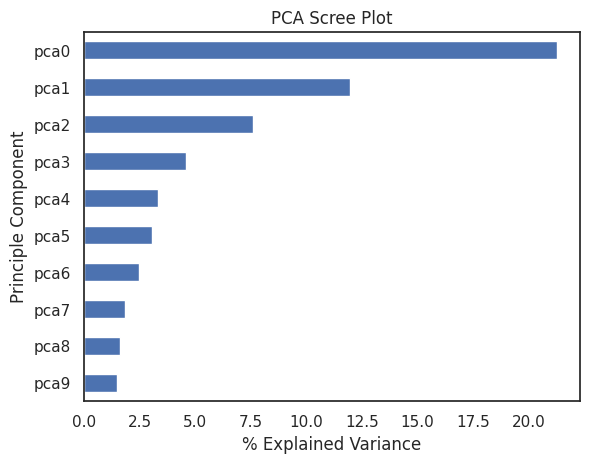

In [6]:
import seaborn as sns
sns.set(style='white')

ax = pd.Series(pca.explained_variance_ratio_ * 100, pca.get_feature_names_out())[::-1][-10:].plot.barh();
ax.set_ylabel("Principle Component")
ax.set_xlabel("% Explained Variance")
ax.set_title("PCA Scree Plot");

This reminds me of a zipfs distribution. The component 1 explains aobut half the variance as component 0, component 2 explains about a third the variance of component 0, component 3 explains aobut a fourth the variance of component 0, etc. I'm not exactly sure what this distrubution means, other than that the first couple of components predict most of the variation in the data.

Additionally I want to note that when I first made this plot component 0 explained more than 60% of the variance, and the others followed the zipf distribution. I guessed that this was because I was working directly with *counts*, not *frequency*, and that component 0 was just looking at the length of the book. After normalizing things look much nicer.

4. Plot results in PCA space and interpret the plot. Use color to plot trends you might expect to see (e.g. author, genre, etc.).

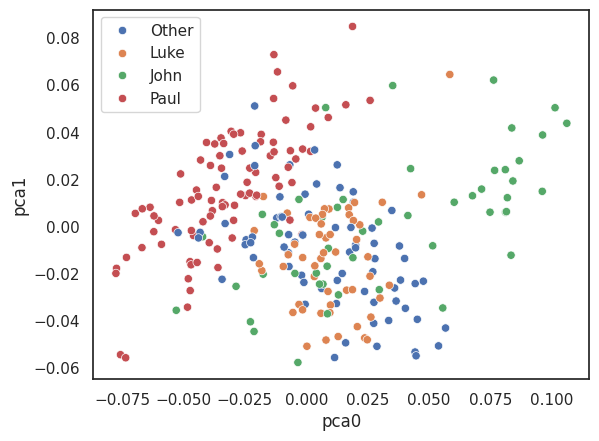

In [7]:
author_map = new_testament_authors = {
    40: "Matthew",
    41: "Mark",
    42: "Luke",
    43: "John",
    44: "Luke",             # Acts
    45: "Paul",             # Romans
    46: "Paul",             # 1 Corinthians
    47: "Paul",             # 2 Corinthians
    48: "Paul",             # Galatians
    49: "Paul",             # Ephesians
    50: "Paul",             # Philippians
    51: "Paul",             # Colossians
    52: "Paul",             # 1 Thessalonians
    53: "Paul",             # 2 Thessalonians
    54: "Paul",             # 1 Timothy
    55: "Paul",             # 2 Timothy
    56: "Paul",             # Titus
    57: "Paul",             # Philemon
    58: "Unknown (traditionally Paul)",  # Hebrews
    59: "James",
    60: "Peter",            # 1 Peter
    61: "Peter",            # 2 Peter
    62: "John",             # 1 John
    63: "John",             # 2 John
    64: "John",             # 3 John
    65: "Jude",
    66: "John"              # Revelation
}
chapter_authors = pcs.index.to_series().str.split(' - ').str[0].astype(int).replace(author_map)
top_3_clusters = chapter_authors.value_counts().index[:3].values
chapter_authors[~chapter_authors.isin(top_3_clusters)] = "Other"
sns.scatterplot(pcs, x='pca0', y='pca1', hue=chapter_authors.values);

5. Quantify separation between clusters. e.g. separation between Pauline books and Johannine books. Do this for 3 different clusters.

6. Repeat steps 1-5 but with the parts of speech feature instead of the Strong's numbers.

7. Use a KNN with a k-fold cross validation for hyper parameter tuning to predict the author of a given pericope (small chunk you must define).

# Side Quests

Perform LDA instead of PCA on the matrix in 1.